In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('goldman_sachs.csv')

In [8]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

In [7]:
monthly = df.groupby(pd.Grouper(key='TransactionDate', freq='M')).agg(
    Credits=('TransactionAmount', lambda x: x[x > 0].sum()),
    Debits=('TransactionAmount', lambda x: abs(x[x < 0].sum())),
    Count=('TransactionID', 'count')
)

In [9]:
monthly['Net'] = monthly['Credits'] - monthly['Debits']

In [10]:
yearly = df.groupby(df['TransactionDate'].dt.year).agg(
    Credits=('TransactionAmount', lambda x: x[x > 0].sum()),
    Debits=('TransactionAmount', lambda x: abs(x[x < 0].sum())),
    Count=('TransactionID', 'count')
)

yearly['Net'] = yearly['Credits'] - yearly['Debits']

In [11]:
print("Monthly:", monthly)
print("\nYearly:", yearly)

Monthly:                       Credits        Debits  Count           Net
TransactionDate                                                 
2023-01-31       3.099865e+06  43218.631912     62  3.056647e+06
2023-02-28       2.083439e+06   1324.168510     37  2.082114e+06
2023-03-31       2.667391e+06  35594.957520     47  2.631796e+06
2023-04-30       1.777616e+06      0.000000     37  1.777616e+06
2023-05-31       2.629305e+06      0.000000     46  2.629305e+06
2023-06-30       1.357006e+06  12026.405360     25  1.344979e+06
2023-07-31       1.577342e+06  22081.442918     36  1.555261e+06
2023-08-31       2.556202e+06      0.000000     49  2.556202e+06
2023-09-30       2.325520e+06      0.000000     48  2.325520e+06
2023-10-31       3.161548e+06   5325.342843     57  3.156223e+06
2023-11-30       2.994017e+06  31070.010213     55  2.962947e+06
2023-12-31       2.288740e+06  17164.686090     43  2.271575e+06
2024-01-31       2.244369e+06   7311.639362     46  2.237057e+06
2024-02-29      

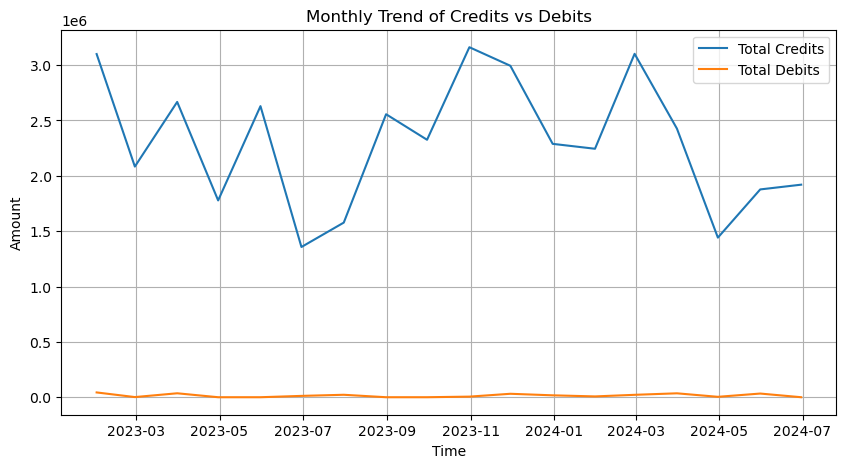

In [13]:
monthly = monthly.reset_index()

plt.figure(figsize=(10,5))

plt.plot(monthly['TransactionDate'], monthly['Credits'], label='Total Credits')
plt.plot(monthly['TransactionDate'], monthly['Debits'], label='Total Debits')

plt.xlabel('Time')
plt.ylabel('Amount')
plt.title('Monthly Trend of Credits vs Debits')
plt.legend()
plt.grid(True)

plt.show()


In [17]:
account_performance = df.groupby('AccountID').agg(
    Credits=('TransactionAmount', lambda x: x[x > 0].sum()),
    Debits=('TransactionAmount', lambda x: abs(x[x < 0].sum()))
)

account_performance['NetInflow'] = (
    account_performance['Credits'] - account_performance['Debits']
)

top_accounts = account_performance.sort_values(
    by='NetInflow', ascending=False
).head(5)

bottom_accounts = account_performance.sort_values(
    by='NetInflow'
).head(5)

print("Top Performing Accounts")
print(top_accounts)

print("\nBottom Performing Accounts")
print(bottom_accounts)


Top Performing Accounts
                Credits       Debits      NetInflow
AccountID                                          
ACC46655   736220.08674  8182.684035  728037.402705
ACC33287   591591.09589     0.000000  591591.095890
ACC16241   539612.14285     0.000000  539612.142850
ACC53466   494957.15880     0.000000  494957.158800
ACC29396   482720.01555     0.000000  482720.015550

Bottom Performing Accounts
               Credits       Debits    NetInflow
AccountID                                       
ACC46953       0.00000  24811.42895 -24811.42895
ACC11062   15601.70053  11587.43563   4014.26490
ACC43771   14033.50256      0.00000  14033.50256
ACC87602   33532.36187  18588.29947  14944.06240
ACC26956   15603.45212      0.00000  15603.45212


In [20]:
df = df.sort_values(by=['AccountID', 'TransactionDate'])


df['PrevDate'] = df.groupby('AccountID')['TransactionDate'].shift(1)
df['GapDays'] = (df['TransactionDate'] - df['PrevDate']).dt.days


df['DormantFlag'] = df['GapDays'] >= 60


dormant_accounts = df[df['DormantFlag'] == True]['AccountID'].unique()

print("Dormant / Inactive Accounts:")
print(dormant_accounts)


Dormant / Inactive Accounts:
['ACC10117' 'ACC10996' 'ACC11062' 'ACC11188' 'ACC11837' 'ACC12182'
 'ACC12334' 'ACC13357' 'ACC15228' 'ACC15359' 'ACC15671' 'ACC15925'
 'ACC16241' 'ACC16664' 'ACC18057' 'ACC18140' 'ACC18177' 'ACC19156'
 'ACC20297' 'ACC21719' 'ACC21878' 'ACC22036' 'ACC22255' 'ACC22799'
 'ACC23736' 'ACC23985' 'ACC24070' 'ACC24880' 'ACC24981' 'ACC25132'
 'ACC25811' 'ACC26026' 'ACC26940' 'ACC26973' 'ACC28154' 'ACC28292'
 'ACC28295' 'ACC28305' 'ACC29007' 'ACC29231' 'ACC29356' 'ACC29396'
 'ACC29477' 'ACC30146' 'ACC30787' 'ACC31539' 'ACC31902' 'ACC32212'
 'ACC32627' 'ACC32890' 'ACC33287' 'ACC34119' 'ACC34431' 'ACC34821'
 'ACC35419' 'ACC36079' 'ACC37688' 'ACC38559' 'ACC39161' 'ACC39482'
 'ACC39500' 'ACC39529' 'ACC39544' 'ACC40939' 'ACC40952' 'ACC41829'
 'ACC42467' 'ACC42710' 'ACC42903' 'ACC45101' 'ACC45521' 'ACC45907'
 'ACC45951' 'ACC46655' 'ACC47099' 'ACC48303' 'ACC48501' 'ACC49180'
 'ACC49364' 'ACC49422' 'ACC49774' 'ACC50439' 'ACC50817' 'ACC51009'
 'ACC51200' 'ACC51593' 'ACC51971'